In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rsicd-image-caption-dataset/valid.csv
/kaggle/input/rsicd-image-caption-dataset/train.csv
/kaggle/input/rsicd-image-caption-dataset/test.csv


In [2]:
import pandas as pd
import numpy as np
import ast
import os
from PIL import Image
import io
from tqdm import tqdm


In [3]:
DATA_DIR = "/kaggle/input/rsicd-image-caption-dataset"
OUT_DIR = "/kaggle/working"

os.makedirs(f"{OUT_DIR}/images", exist_ok=True)


In [4]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/valid.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)


Train: (8734, 3)
Val  : (1094, 3)
Test : (1093, 3)


In [5]:
train_df.columns

Index(['filename', 'captions', 'image'], dtype='object')

In [6]:
train_df

,filename,captions,image
0,rsicd_images/airport_1.jpg,['Many aircraft are parked next to a long buil...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1,rsicd_images/airport_10.jpg,['some planes are parked in an airport.'\n 'th...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,rsicd_images/airport_100.jpg,['Many aircraft are parked in an airport near ...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
3,rsicd_images/airport_101.jpg,['Many aircraft are parked near a large buildi...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,rsicd_images/airport_102.jpg,['several buildings and green trees are around...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
...,...,...,...
8729,rsicd_images/00914.jpg,['the majestic polygonal baseball field can co...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
8730,rsicd_images/00915.jpg,['the baseball field is near the residential a...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
8731,rsicd_images/00916.jpg,"['on the side of the road, there are two baseb...",{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
8732,rsicd_images/00918.jpg,['this is a huge baseball field decorated with...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...


In [7]:
train_df['captions'][0]

"['Many aircraft are parked next to a long building in an airport.'\n 'Many planes are parked next to a long building at an airport.'\n 'Many planes are parked next to a long building in an airport.'\n 'many planes are parked next to a long building at an airport.'\n 'many planes are parked next to a long building in an airport .']"

In [8]:
def count_captions(df):
    return df["captions"].apply(lambda x: len(ast.literal_eval(x))).describe()

count_captions(train_df)


count    8734.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: captions, dtype: float64

In [9]:
def caption_lengths(df):
    lens = []
    for caps in df["captions"]:
        caps = ast.literal_eval(caps)
        for c in caps:
            lens.append(len(c.split()))
    return pd.Series(lens).describe()

caption_lengths(train_df)


count    8734.000000
mean       52.017632
std        13.715673
min        20.000000
25%        42.000000
50%        51.000000
75%        60.000000
max       118.000000
dtype: float64

In [10]:
def extract_images(df, split):
    out_path = f"{OUT_DIR}/images/{split}"
    os.makedirs(out_path, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_bytes = eval(row["image"])["bytes"]
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        img_name = row["filename"].split("/")[-1]
        img.save(f"{out_path}/{img_name}")


In [11]:
extract_images(train_df, "train")
extract_images(val_df, "val")
extract_images(test_df, "test")

100%|██████████| 1093/1093 [00:03<00:00, 353.88it/s]


In [12]:
def parse_captions(caption_str):
    # remove surrounding brackets
    caption_str = caption_str.strip()[1:-1]

    # split by newline
    captions = caption_str.split("\n")

    # clean each caption
    captions = [
        c.strip().strip("'").strip('"')
        for c in captions
        if len(c.strip()) > 0
    ]

    return captions


In [13]:
example = train_df.iloc[0]["captions"]
parsed = parse_captions(example)

print(len(parsed))
for c in parsed:
    print("-", c)


5
- Many aircraft are parked next to a long building in an airport.
- Many planes are parked next to a long building at an airport.
- Many planes are parked next to a long building in an airport.
- many planes are parked next to a long building at an airport.
- many planes are parked next to a long building in an airport .


In [14]:
import ast
import pandas as pd

OUT_DIR = "/kaggle/working"

def flatten_dataset(df, split):
    rows = []

    for _, row in df.iterrows():
        img_name = row["filename"].split("/")[-1]
        img_path = f"/kaggle/working/images/{split}/{img_name}"

        captions = parse_captions(row["captions"])

        for cap in captions:
            rows.append({
                "image_path": img_path,
                "caption": cap.lower().strip()
            })

    return pd.DataFrame(rows)

train_flat = flatten_dataset(train_df, "train")
val_flat   = flatten_dataset(val_df, "val")
test_flat  = flatten_dataset(test_df, "test")

train_flat.to_csv("/kaggle/working/train_clip.csv", index=False)
val_flat.to_csv("/kaggle/working/val_clip.csv", index=False)
test_flat.to_csv("/kaggle/working/test_clip.csv", index=False)


In [15]:
assert train_flat["image_path"].apply(os.path.exists).all()
assert train_flat["caption"].str.len().mean() > 30

In [16]:
!pip install -q transformers torch torchvision accelerate

In [17]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel


2026-02-08 15:58:36.318701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770566316.532786      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770566316.595033      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770566317.134685      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770566317.134724      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770566317.134726      24 computation_placer.cc:177] computation placer alr

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Number of GPUs:", torch.cuda.device_count())

Device: cuda
Number of GPUs: 2


In [19]:
train_df = pd.read_csv("/kaggle/working/train_clip.csv")
val_df   = pd.read_csv("/kaggle/working/val_clip.csv")

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 42548
Val samples: 5148


In [20]:
train_df = pd.read_csv("/kaggle/working/train_clip.csv")
val_df   = pd.read_csv("/kaggle/working/val_clip.csv")

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 42548
Val samples: 5148


In [21]:
train_df

,image_path,caption
0,/kaggle/working/images/train/airport_1.jpg,many aircraft are parked next to a long buildi...
1,/kaggle/working/images/train/airport_1.jpg,many planes are parked next to a long building...
2,/kaggle/working/images/train/airport_1.jpg,many planes are parked next to a long building...
3,/kaggle/working/images/train/airport_1.jpg,many planes are parked next to a long building...
4,/kaggle/working/images/train/airport_1.jpg,many planes are parked next to a long building...
...,...,...
42543,/kaggle/working/images/train/00920.jpg,two baseball fields are located in the huage a...
42544,/kaggle/working/images/train/00920.jpg,two baseball fields are in one side of a road .
42545,/kaggle/working/images/train/00920.jpg,two baseball grounds are next to a road and a ...
42546,/kaggle/working/images/train/00920.jpg,two baseball fields are next to a road and a p...


In [22]:
class CLIPDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        caption = row["caption"]

        inputs = self.processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding="max_length",
            truncation=True
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0)
        }


In [23]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [24]:
if torch.cuda.device_count() > 1:
    print("Using DataParallel with", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

model = model.to(device)

Using DataParallel with 2 GPUs


In [25]:
train_dataset = CLIPDataset(train_df, processor)
val_dataset   = CLIPDataset(val_df, processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [26]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)


In [27]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        optimizer.zero_grad()

        outputs = model(
            pixel_values=batch["pixel_values"].to(device),
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            return_loss=True
        )

        loss = outputs.loss.mean()   # ⭐ FIX IS HERE
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [28]:
def validate_one_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                pixel_values=batch["pixel_values"].to(device),
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                return_loss=True
            )

            loss = outputs.loss.mean()   # ⭐ FIX
            total_loss += loss.item()

    return total_loss / len(loader)


In [29]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss   = validate_one_epoch(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val   Loss: {val_loss:.4f}")


  0%|          | 0/1330 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
100%|██████████| 1330/1330 [09:08<00:00,  2.42it/s]



Epoch 1/5
Train Loss: 0.3958
Val   Loss: 2.8396


100%|██████████| 1330/1330 [09:20<00:00,  2.37it/s]



Epoch 2/5
Train Loss: 0.2162
Val   Loss: 3.0068


100%|██████████| 1330/1330 [09:20<00:00,  2.37it/s]



Epoch 3/5
Train Loss: 0.1671
Val   Loss: 3.0738


100%|██████████| 1330/1330 [09:21<00:00,  2.37it/s]



Epoch 4/5
Train Loss: 0.1394
Val   Loss: 3.1194


100%|██████████| 1330/1330 [09:20<00:00,  2.37it/s]



Epoch 5/5
Train Loss: 0.1196
Val   Loss: 3.2275


In [30]:
save_path = "/kaggle/working/clip-rsicd"

if isinstance(model, torch.nn.DataParallel):
    model.module.save_pretrained(save_path)
else:
    model.save_pretrained(save_path)

processor.save_pretrained(save_path)

print("Model saved to:", save_path)


Model saved to: /kaggle/working/clip-rsicd


In [31]:
!zip -r clip-rsicd.zip /kaggle/working/clip-rsicd

  adding: kaggle/working/clip-rsicd/ (stored 0%)
  adding: kaggle/working/clip-rsicd/special_tokens_map.json (deflated 78%)
  adding: kaggle/working/clip-rsicd/merges.txt (deflated 60%)
  adding: kaggle/working/clip-rsicd/config.json (deflated 66%)
  adding: kaggle/working/clip-rsicd/preprocessor_config.json (deflated 50%)
  adding: kaggle/working/clip-rsicd/model.safetensors (deflated 7%)
  adding: kaggle/working/clip-rsicd/tokenizer_config.json (deflated 63%)
  adding: kaggle/working/clip-rsicd/tokenizer.json (deflated 83%)
  adding: kaggle/working/clip-rsicd/vocab.json (deflated 62%)


In [32]:
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import pandas as pd

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained("/kaggle/working/clip-rsicd")
processor = CLIPProcessor.from_pretrained("/kaggle/working/clip-rsicd")

model = model.to(device)
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [34]:
val_df = pd.read_csv("/kaggle/working/val_clip.csv")

# unique images only
image_paths = val_df["image_path"].unique()

In [35]:
import numpy as np
from tqdm import tqdm

image_embeddings = []

with torch.no_grad():
    for img_path in tqdm(image_paths):
        image = Image.open(img_path).convert("RGB")

        inputs = processor(images=image, return_tensors="pt").to(device)
        emb = model.get_image_features(**inputs)

        emb = emb / emb.norm(dim=-1, keepdim=True)
        image_embeddings.append(emb.cpu())

image_embeddings = torch.cat(image_embeddings)

100%|██████████| 1094/1094 [00:09<00:00, 115.47it/s]


In [36]:
query = "an airport with multiple airplanes and multiple runway"
# query = "industrial buildings near roads"
# query = "an airport with a single runway"


inputs = processor(text=query, return_tensors="pt").to(device)

with torch.no_grad():
    text_emb = model.get_text_features(**inputs)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)


In [37]:
# normalize already done
text_emb = text_emb.cpu()

similarities = (text_emb @ image_embeddings.T).squeeze(0)

top_k = similarities.topk(5).indices.tolist()

top_k_image_paths = []
for idx in top_k:
    print(image_paths[idx])
    top_k_image_paths.append(image_paths[idx])


/kaggle/working/images/val/airport_94.jpg
/kaggle/working/images/val/airport_67.jpg
/kaggle/working/images/val/airport_80.jpg
/kaggle/working/images/val/airport_75.jpg
/kaggle/working/images/val/airport_61.jpg


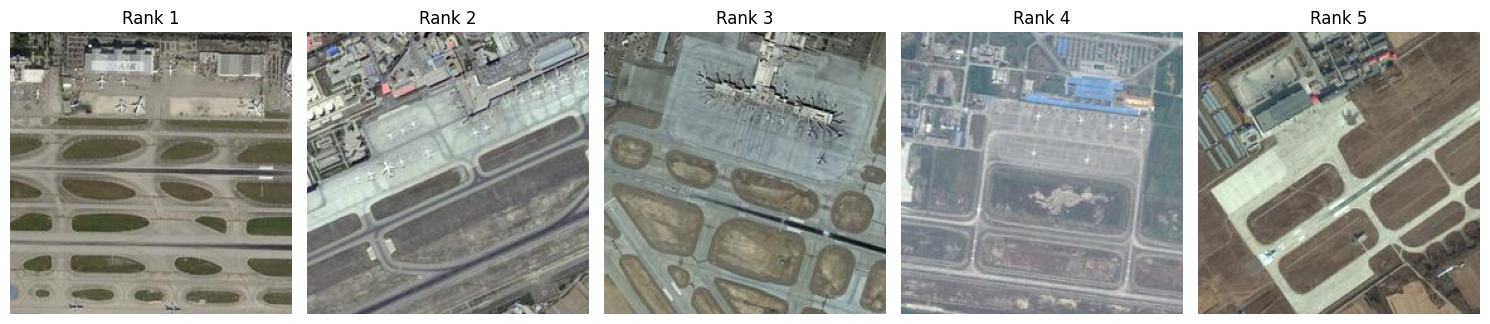

In [38]:
from PIL import Image
import matplotlib.pyplot as plt

retrieved_paths = top_k_image_paths

plt.figure(figsize=(15, 5))

for i, path in enumerate(retrieved_paths):
    img = Image.open(path).convert("RGB")
    plt.subplot(1, len(retrieved_paths), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Rank {i+1}")

plt.tight_layout()
plt.show()
